In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first 5 rows in a clean table format
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check the names of all 21 columns, their data types, and if there are null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Force TotalCharges to be numeric. Blank spaces will turn into 'NaN' (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many blank/null values we just uncovered
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 11


In [5]:
# Drop rows where TotalCharges is missing
df.dropna(subset=['TotalCharges'], inplace=True)

# Confirm everything is clean now
print("Remaining rows in dataset:", df.shape[0])

Remaining rows in dataset: 7032


In [6]:
# Count how many customers stayed (No) vs left (Yes)
print("--- CHURN COUNTS ---")
print(df['Churn'].value_counts())

print("\n--- PERCENTAGE CHURN RATE ---")
print(df['Churn'].value_counts(normalize=True) * 100)

--- CHURN COUNTS ---
Churn
No     5163
Yes    1869
Name: count, dtype: int64

--- PERCENTAGE CHURN RATE ---
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


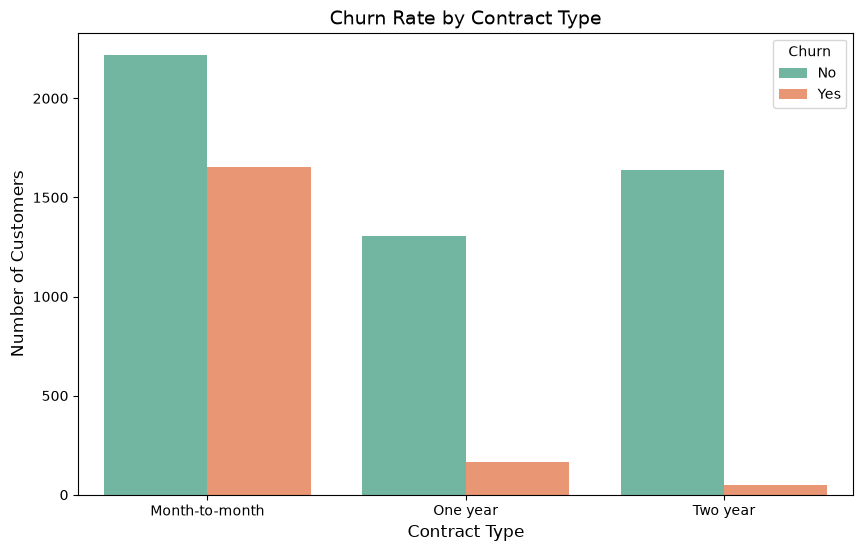

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting window size
plt.figure(figsize=(10, 6))

# Create a countplot showing Churn behavior across different contract types
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')

# Add titles and labels to make it look professional
plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Show the plot
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14228\1864416166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Pastel1')


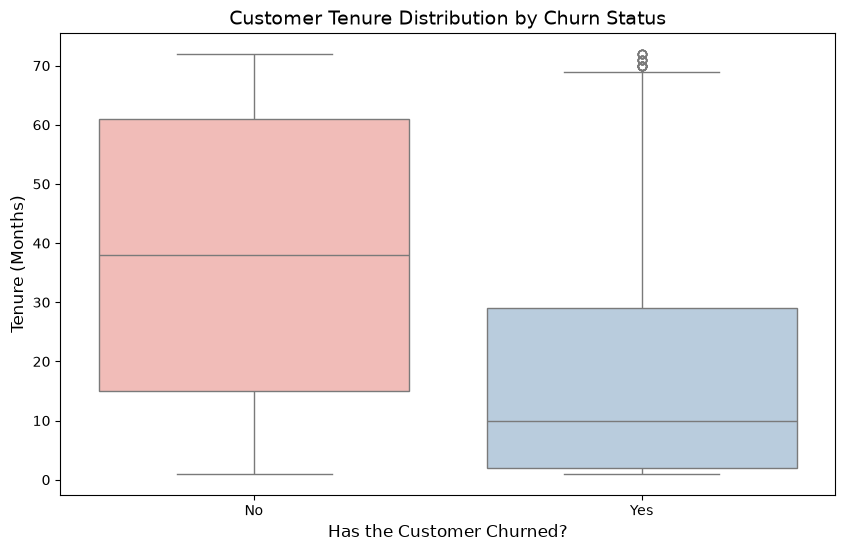

In [8]:
plt.figure(figsize=(10, 6))

# Create a boxplot to show the distribution of tenure for those who left vs stayed
sns.boxplot(data=df, x='Churn', y='tenure', palette='Pastel1')

plt.title('Customer Tenure Distribution by Churn Status', fontsize=14)
plt.xlabel('Has the Customer Churned?', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)

plt.show()

In [9]:
# Drop customerID since it has no predictive power
df.drop(columns=['customerID'], inplace=True)

# Confirm it's gone by checking the dataset's columns and rows
print("New shape of dataset:", df.shape)

New shape of dataset: (7032, 20)


In [10]:
# Convert all categorical text columns into 1s and 0s
# We use dtype=int to keep it clean as standard 1 and 0 integers
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

# Look at the first 3 rows of our completely numerical dataset
df_encoded.head(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1


In [11]:
# 'Churn_Yes' is our target variable. We drop it from X to create our features.
X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (7032, 30)
Target shape (y): (7032,)


In [12]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 5625
Testing samples: 1407


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the model
model = RandomForestClassifier(random_state=42)

# Train the model using our training data
model.fit(X_train, y_train)

# Make predictions on the unseen test data
y_pred = model.predict(X_test)

# Print performance results
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\n--- Detailed Performance Classification Report ---")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7896233120113717

--- Detailed Performance Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



C:\Users\Admin\AppData\Local\Temp\ipykernel_14228\2530411674.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


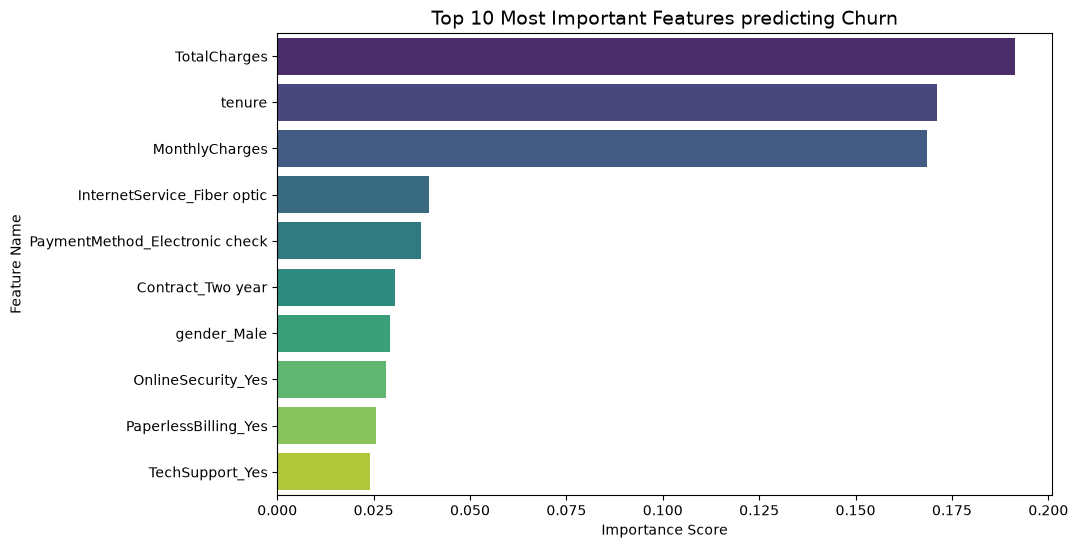

In [14]:
# Extract feature importance from our Random Forest model
importances = model.feature_importances_
feature_names = X.columns

# Create a clean DataFrame to sort them
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features predicting Churn', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

In [16]:
import pickle

# Corrected function: pickle.dump() transfers the model brain to the file
with open('churn_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

# Save the exact list of feature columns so our app handles inputs correctly
with open('model_features.pkl', 'wb') as features_file:
    pickle.dump(list(X.columns), features_file)

print("🎉 Model and features successfully saved to your folder!")

🎉 Model and features successfully saved to your folder!


In [17]:
pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.2 MB 2.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.2 MB 3.5 MB/s eta 0:00:03
   ---------- ----------------------------- 2.4/9.2 MB 3.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.2 MB 4.2 MB/s eta 0:00:02
   ------------------- -------------------- 4.5/9.2 MB 4.4 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.2 MB 4.6 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.2 MB 4.7 MB/s eta 0:00:01
   ---------------------------------- ----- 7.9/9.2 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.2 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 4.7 MB/s  0:00:02
   ---------------------------------------- 0.0/797.5 kB ? eta -:--:--
   ---------------------------------------- 797.5/797.5 kB 5.2 MB/s  0:00:00
   -----------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
